## Galaxies in Illustris

Above, we were looking at star particles in simulated galaxies, similar to how we looked at stars in the Milky Way using Gaia data. We can instead look at many galaxies' overall properties, similar to how we looked at galaxies in Galaxy Zoo. We can look at some of the fully evolved galaxies in IllustrisTNG by examining the Illustris_galaxies file in the Data folder.

In [44]:
# read in the data (Illustris_galaxies.csv)
import pandas as pd


dataI = pd.read_csv('../Data/Illustris_galaxies.csv') 

In [47]:
# display the data set
dataI

,Galaxy ID,Stellar Mass [Mo],g band,r band,Probability is spiral
0,0,3.565573e+12,-23.256830,-24.071047,0.285813
1,1,5.376783e+11,-21.941610,-22.712160,0.817303
2,2,6.034437e+11,-22.199574,-22.951138,0.941455
3,3,1.650696e+11,-21.828701,-22.411537,0.998825
4,4,1.283022e+11,-20.685863,-21.426640,0.113466
...,...,...,...,...,...
12530,704187,5.030724e+09,-17.602875,-18.358276,0.411240
12531,719337,6.327700e+09,-18.095821,-18.824528,0.607696
12532,727485,5.224962e+09,-17.727982,-18.471638,0.475961
12533,738596,3.874592e+09,-17.392363,-18.134193,0.542526


**How many rows are there?** 

**Answer:** 12535

**How many columns are there?** 

**Answer:** 5

**Fill in the rows for each corresponding column**

| Column Header | Definition | Unit |
| :- | :- | :- |
| Galaxy ID |  identifier for each galaxy | 
| Stellar Mass [Mo] | The total mass of stars in the galaxy | Solar masses 
| g band | magnitude of the galaxy  | MT
| r band | absolute magnitude | Magnitude
| Probability is spiral |  that the galaxy is a spiral | 0-1

In [71]:
import pandas as pd

# Read in the data
dataI

# Check actual column names
print(data.columns)  # Run this once to see the exact names

# Rename column for ease of use 
data = data.rename(columns={'Probability is spiral': 'prob_spiral'})
g = dataI['g band']
r = dataI['r band']

# Create boolean arrays
spiral = data['prob_spiral'] >= 0.5
elliptical = data['prob_spiral'] < 0.2

# Print counts
print(f"Number of spiral galaxies: {spiral.sum()}")
print(f"Number of elliptical galaxies: {elliptical.sum()}")


Index(['Galaxy ID', 'Stellar Mass [Mo]', 'g band', 'r band', 'prob_spiral'], dtype='object')
Number of spiral galaxies: 7418
Number of elliptical galaxies: 1474


**What percentage of these galaxies are spirals?**

**Answer:** 

**What percentage of these galaxies are ellipticals?**

**Answer:** 

In [72]:
#fill in the name of the boolean arrays where you see $
print('The percentage of spiral galaxies is', round(sum(data['prob_spiral'])/len(spiral) * 100,2), '%')
print('The percentage of elliptical galaxies is', round(sum(spiral)/len(elliptical) * 100,2), '%')

The percentage of spiral galaxies is 57.47 %
The percentage of elliptical galaxies is 59.18 %


**How do these percentages compare to the ones you found in the Galaxy Zoo data?**

**Answer:** 

Number of spiral galaxies: 7418
Number of elliptical galaxies: 1474


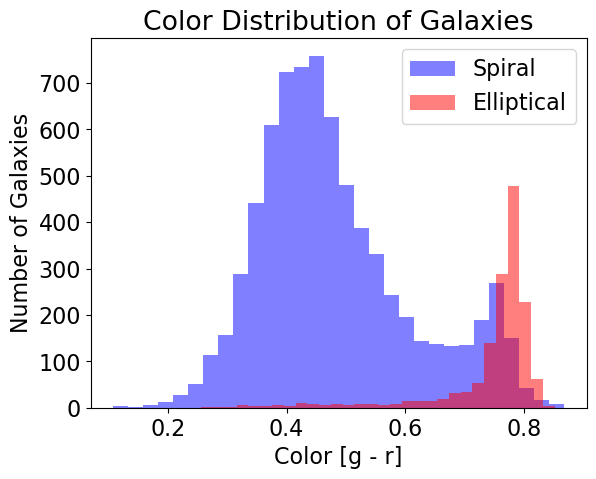

Spiral Mean Color: 0.4821860647074683
Spiral Std Dev: 0.13013457462932912
Elliptical Mean Color: 0.7470766377204884
Elliptical Std Dev: 0.0864284419307444


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', **{'family':'sans-serif', 'size':16}) 

# Load data
dataI = pd.read_csv("../Data/Illustris_galaxies.csv")  # Replace with actual file path
data = dataI.copy()

# Rename for convenience
data = data.rename(columns={'Probability is spiral': 'prob_spiral'})

# Extract magnitudes
g = data['g band']
r = data['r band']
color = g - r

# Apply masks
spiral = data['prob_spiral'] >= 0.5
elliptical = data['prob_spiral'] < 0.2

# Print counts
print(f"Number of spiral galaxies: {spiral.sum()}")
print(f"Number of elliptical galaxies: {elliptical.sum()}")

# Plot histogram
plt.hist(color[spiral], bins=30, alpha=0.5, label='Spiral', color='blue')
plt.hist(color[elliptical], bins=30, alpha=0.5, label='Elliptical', color='red')
plt.xlabel('Color [g - r]')
plt.ylabel('Number of Galaxies')
plt.title('Color Distribution of Galaxies')
plt.legend()
plt.show()

# Statistics
print("Spiral Mean Color:", color[spiral].mean())
print("Spiral Std Dev:", color[spiral].std())
print("Elliptical Mean Color:", color[elliptical].mean())
print("Elliptical Std Dev:", color[elliptical].std())


**Are your results consistent with what you found in Galaxy Zoo?**

**Answer:**

## Mergers

So far, we have confirmed that in at least some ways, the simulated galaxies behave like observed ones! Cool, but let's learn something new! I said that we can use galaxy simulations to learn about mergers. Let's do that! Read in the mergers files and check out what it contains. 

In [74]:
# read in the file mergers.csv
import pandas as pd


dataM = pd.read_csv('../Data/mergers.csv') 


In [75]:
# examine the data
dataM

,Galaxy ID,Time Since Last Major Merger [Gyr],Number of Major Mergers,Numbber of Minor Mergers
0,0,5.740040,8,16
1,1,3.956615,9,5
2,2,0.799699,3,4
3,3,4.126383,7,5
4,4,6.980874,5,7
...,...,...,...,...
12530,704187,12.554805,3,2
12531,719337,9.462953,1,2
12532,727485,10.228946,7,1
12533,738596,11.317041,3,2


**How many rows are there?** 

**Answer:** 12535

**How many columns are there?**

**Answer:** 4

**Fill in the rows for each corresponding column**

| Column Header | Definition | Unit |
| :- | :- | :- |
| Galaxy ID |  identifier for each galaxy in your dataset | 
| Time Since Last Major Merger [Gyr] | Time that passed for a galaxy to have a major merge | Gyr
| Number of Major Mergers | Total number of major merges | 
| Number of Minor Mergers | Total number of minor merges | 

# Deliverable

Explore the galaxy data you have in this notebook to make at least one plot that tells us something we haven't explored! Be ready to present. You might want to include statistics.

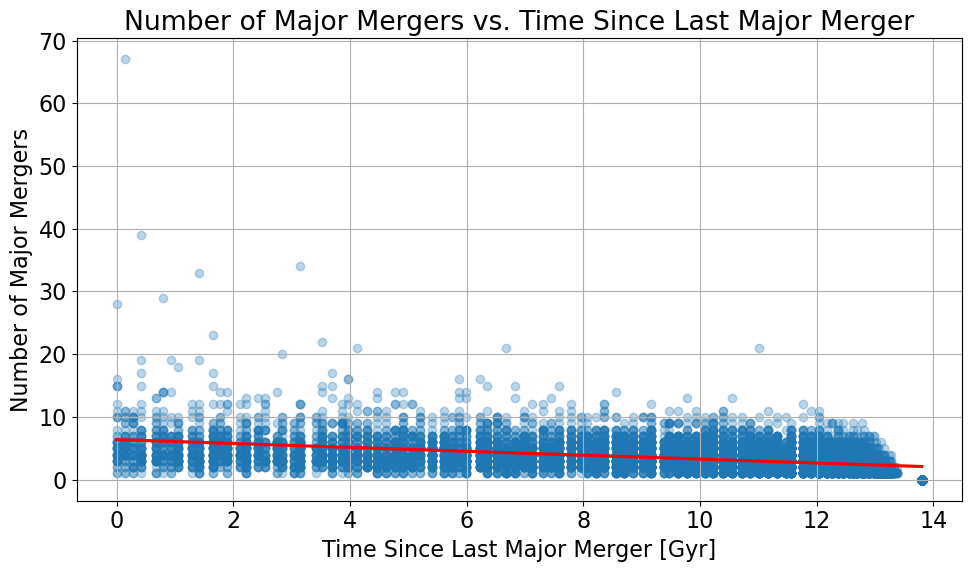

Mean Time Since Last Major Merger: 9.55 Gyr
Mean Number of Major Mergers: 3.42
Pearson Correlation Coefficient: -0.46 (p-value: 0.00e+00)


In [79]:
# explore the data and make a plot below!

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../Data/mergers.csv')

# Column rename
df = df.rename(columns={"Numbber of Minor Mergers": "Number of Minor Mergers"})

# Plot: Number of Major Mergers vs. Time Since Last Major Merger
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='Time Since Last Major Merger [Gyr]',
    y='Number of Major Mergers',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Number of Major Mergers vs. Time Since Last Major Merger')
plt.xlabel('Time Since Last Major Merger [Gyr]')
plt.ylabel('Number of Major Mergers')
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary statistics and correlation
mean_time = df['Time Since Last Major Merger [Gyr]'].mean()
mean_mergers = df['Number of Major Mergers'].mean()
correlation, p_value = stats.pearsonr(
    df['Time Since Last Major Merger [Gyr]'],
    df['Number of Major Mergers']
)

print(f"Mean Time Since Last Major Merger: {mean_time:.2f} Gyr")
print(f"Mean Number of Major Mergers: {mean_mergers:.2f}")
print(f"Pearson Correlation Coefficient: {correlation:.2f} (p-value: {p_value:.2e})")


**According to your graph set up...**

**What is the independent variable?**

**Answer:** Time since last merger 


**What is the dependent variable?**

**Answer:** Number of Major mergers


**What could a control variable be?**

**Answer:** Galaxy Mass or Size

**What shapes or trends do you see in the data?**

**Answer:** Negative trend, Clusters

**What could this mean physically/astronomically?**

**Answer:** Galaxies with recent mergers are going to have more mergers 
while older galaxies have less mergers

this also means that galaxies are still evolving and also older ones are going to create bigger black holes 

**What further questions does this raise?**

**Answer:** how does this effect other galaxies or how about the star formations

## Reflection

Write down some notes in your lab notebook about what you've learned in this unit about simulated galaxies. Be sure to include some astronomy and some coding. 